В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [64]:
import os
import warnings
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, f1_score

train_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/train.csv')
display(train_df)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
10162,10162,15573077.0,Efimov,710.0,Germany,Female,29.0,4.0,116927.89,1.0,1.0,1.0,60905.51,1.0
9706,9706,15733261.0,K?,583.0,France,Female,30.0,1.0,0.00,1.0,0.0,1.0,38652.96,0.0
11547,11547,15770309.0,Shih,748.0,Spain,Male,38.0,9.0,0.00,2.0,0.0,0.0,131660.31,0.0
7342,7342,15700965.0,Scott,686.0,Spain,Female,43.0,6.0,0.00,2.0,1.0,1.0,82522.61,0.0
14335,14335,15749050.0,Nnonso,649.0,Spain,Male,35.0,8.0,0.00,2.0,1.0,0.0,91906.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2386,2386,15585379.0,P'eng,572.0,France,Female,38.0,3.0,0.00,2.0,1.0,1.0,142331.85,0.0
4553,4553,15694321.0,Okechukwu,706.0,Germany,Male,35.0,4.0,116077.48,2.0,1.0,1.0,123435.88,0.0
10319,10319,15780961.0,Chikezie,697.0,France,Male,44.0,2.0,0.00,2.0,1.0,0.0,119127.06,0.0
1032,1032,15736287.0,Milanesi,664.0,Germany,Male,40.0,1.0,76319.64,1.0,1.0,0.0,63736.17,1.0


In [65]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['Exited']
)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [66]:
input_cols = train_df.drop(columns=['Exited']).columns.tolist()[2:]
target_col = ['Exited']

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [67]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Interaction features
    df['Age_x_Balance'] = df['Age'] * df['Balance']
    df['Products_x_Tenure'] = df['NumOfProducts'] * df['Tenure']

    # Binned features as strings so they are treated as categorical later
    df['Age_bin'] = pd.cut(
        df['Age'],
        bins=[-1, 30, 45, 60, 200],
        labels=['lt_30', '30_45', '45_60', '60_plus'],
        include_lowest=True
    ).astype(str)

    df['CreditScore_bin'] = pd.cut(
        df['CreditScore'],
        bins=[-1, 500, 650, 750, 1000],
        labels=['low', 'mid', 'high', 'very_high'],
        include_lowest=True
    ).astype(str)

    return df

train_inputs = add_engineered_features(train_inputs)
val_inputs = add_engineered_features(val_inputs)

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [68]:
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

Ознайомлюємось з даними

In [69]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6144 entries, 4479 to 11205
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Surname            6144 non-null   object 
 1   CreditScore        6144 non-null   float64
 2   Geography          6144 non-null   object 
 3   Gender             6144 non-null   object 
 4   Age                6144 non-null   float64
 5   Tenure             6144 non-null   float64
 6   Balance            6144 non-null   float64
 7   NumOfProducts      6144 non-null   float64
 8   HasCrCard          6144 non-null   float64
 9   IsActiveMember     6144 non-null   float64
 10  EstimatedSalary    6144 non-null   float64
 11  Age_x_Balance      6144 non-null   float64
 12  Products_x_Tenure  6144 non-null   float64
 13  Age_bin            6144 non-null   object 
 14  CreditScore_bin    6144 non-null   object 
dtypes: float64(10), object(5)
memory usage: 768.0+ KB


In [70]:
train_inputs.isna().sum()

Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Age_x_Balance        0
Products_x_Tenure    0
Age_bin              0
CreditScore_bin      0
dtype: int64

Бачимо, що всі дані заповнені. Пропущені колонки відсутні.

In [71]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Age_x_Balance,Products_x_Tenure
count,6144.00,6144.00,6144.00,6144.00,6144.00,6144.00,6144.00,6144.00,6144.00,6144.00
mean,658.43,37.70,5.04,43473.59,1.59,0.79,0.49,118235.84,1685849.05,7.99
std,72.48,8.19,2.78,60148.95,0.53,0.41,0.50,45657.39,2419844.86,5.34
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00,0.00
25%,602.00,32.00,3.00,0.00,1.00,1.00,0.00,83419.44,0.00,4.00
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123882.73,0.00,7.00
75%,708.00,42.00,7.00,110151.14,2.00,1.00,1.00,156911.35,3923737.77,12.00
max,850.00,72.00,10.00,209767.31,4.00,1.00,1.00,199992.48,11063755.44,36.00


Числові колонки не мають пропущених значень і на перший погляд виглядають логічними. Будемо їх масштабувати, щоб значення були в одному діапазоні.

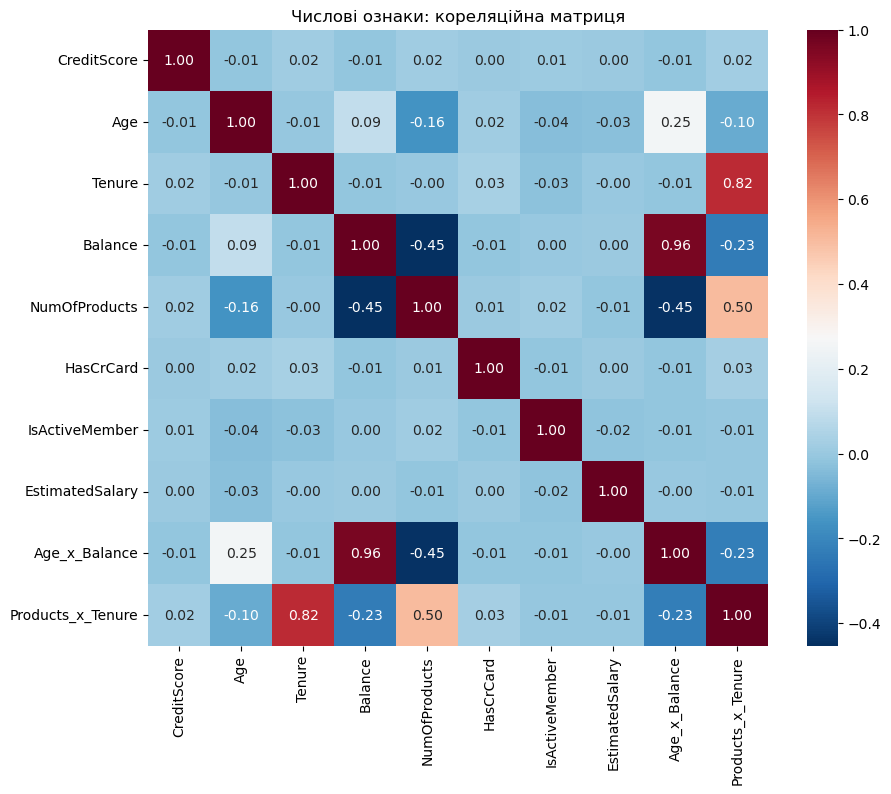

In [72]:
plt.figure(figsize=(10, 8))
corr = train_inputs[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Числові ознаки: кореляційна матриця')
plt.savefig('corr_numeric_features.png', dpi=300, bbox_inches='tight')
plt.show()

Після побудови кореляційної матриці бачимо, що більшість числових ознак не мають дуже сильних лінійних зв’язків між собою. Це означає, що дані в цілому добре підходять для подальшого навчання моделі. Водночас окремі ознаки можуть бути корисними для прогнозування відтоку клієнтів, тому їх залишаємо для моделі.

In [73]:
train_targets[target_col].value_counts(normalize = True)

Exited
0.0       0.796549
1.0       0.203451
Name: proportion, dtype: float64

In [74]:
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [75]:
train_inputs[numeric_cols]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Age_x_Balance,Products_x_Tenure
4479,0.763723,0.203704,0.3,0.000000,0.333333,1.0,1.0,0.523604,0.000000,0.166667
14655,0.381862,0.333333,0.6,0.000000,0.333333,1.0,1.0,0.607521,0.000000,0.333333
10732,0.460621,0.111111,0.1,0.000000,0.333333,1.0,1.0,0.242761,0.000000,0.055556
6165,0.377088,0.370370,0.8,0.000000,0.000000,0.0,0.0,0.596740,0.000000,0.222222
9226,0.894988,0.518519,0.3,0.000000,0.000000,1.0,1.0,0.495630,0.000000,0.083333
...,...,...,...,...,...,...,...,...,...,...
618,0.415274,0.203704,0.6,0.575817,0.000000,1.0,0.0,0.649459,0.316605,0.166667
11277,0.558473,0.481481,0.1,0.498115,0.000000,1.0,1.0,0.289059,0.415544,0.027778
14760,0.651551,0.814815,0.6,0.555369,0.666667,1.0,0.0,0.599515,0.652842,0.500000
14039,0.467780,0.222222,0.3,0.540518,0.000000,1.0,1.0,0.507447,0.307445,0.083333


In [76]:
from sklearn.preprocessing import OneHotEncoder

In [77]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [78]:
train_inputs[categorical_cols].nunique()

Surname            614
Geography            3
Gender               2
Age_bin              4
CreditScore_bin      4
dtype: int64

Колонка `Surname` є нерелевантною для побудови моделі, тому ми не будемо її використовувати. Будемо кодувати дві інші колонки.

In [79]:
categorical_cols = train_inputs.drop(columns=['Surname']).select_dtypes(include='object').columns.tolist()
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male', 'Age_bin_30_45', 'Age_bin_45_60', 'Age_bin_60_plus', 'Age_bin_lt_30', 'CreditScore_bin_high', 'CreditScore_bin_low', 'CreditScore_bin_mid', 'CreditScore_bin_very_high']


In [80]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [81]:
display(train_inputs.head())

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,...,Gender_Female,Gender_Male,Age_bin_30_45,Age_bin_45_60,Age_bin_60_plus,Age_bin_lt_30,CreditScore_bin_high,CreditScore_bin_low,CreditScore_bin_mid,CreditScore_bin_very_high
4479,Hsia,0.763723,Spain,Male,0.203704,0.3,0.0,0.333333,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
14655,Ch'iu,0.381862,Spain,Male,0.333333,0.6,0.0,0.333333,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10732,Ch'ang,0.460621,France,Male,0.111111,0.1,0.0,0.333333,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6165,Tung,0.377088,Spain,Female,0.370370,0.8,0.0,0.000000,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9226,Hsueh,0.894988,France,Female,0.518519,0.3,0.0,0.000000,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [82]:
display(val_inputs.head())

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,...,Gender_Female,Gender_Male,Age_bin_30_45,Age_bin_45_60,Age_bin_60_plus,Age_bin_lt_30,CreditScore_bin_high,CreditScore_bin_low,CreditScore_bin_mid,CreditScore_bin_very_high
11084,Fan,0.610979,Germany,Female,0.500000,0.7,0.441799,0.666667,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4406,Trevisano,0.606205,France,Female,0.203704,0.4,0.000000,0.333333,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
6577,Ogochukwu,0.429594,France,Male,0.222222,0.7,0.809624,0.000000,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9276,Chuang,0.868735,Germany,Male,0.240741,0.1,0.575482,0.333333,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10411,Pisani,0.699284,Germany,Female,0.462963,0.4,0.550434,0.000000,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [83]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (6144, 28)
train_targets: (6144, 1)
val_inputs: (1536, 28)
val_targets: (1536, 1)


In [84]:
out_dir = '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/prepared_data'

train_inputs.to_parquet(f'{out_dir}/train_inputs.parquet')
train_targets.to_parquet(f'{out_dir}/train_targets.parquet')
val_inputs.to_parquet(f'{out_dir}/val_inputs.parquet')
val_targets.to_parquet(f'{out_dir}/val_targets.parquet')

In [85]:
import os

In [86]:
os.listdir(out_dir)

['train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [87]:
model = LogisticRegression(solver='liblinear')
model.fit(train_inputs[numeric_cols + encoded_cols], train_targets)

c:\Users\akore\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(solver='liblinear')

In [88]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

train_preds = model.predict(X_train)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

## Confusion matrix

In [90]:
cf = confusion_matrix(train_targets, train_preds, normalize='true')
cf

array([[0.96117695, 0.03882305],
       [0.4464    , 0.5536    ]])

In [91]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='viridis', fmt='.2f', annot_kws={"color": "white"})
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.83%


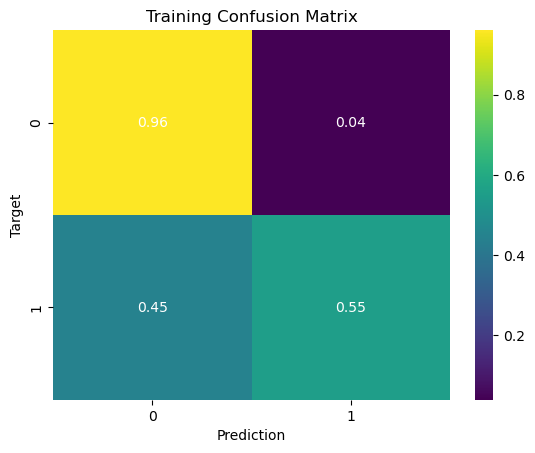

In [92]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.37%


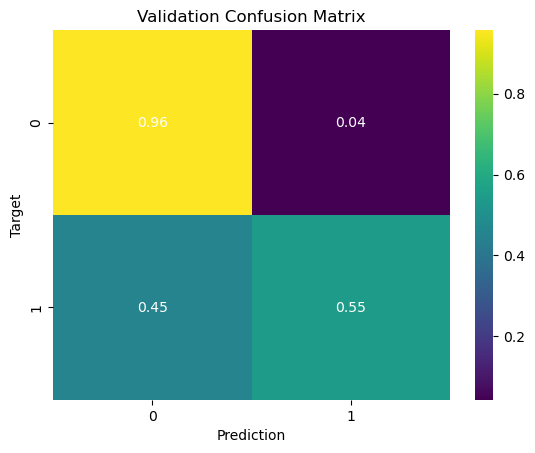

In [93]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

## ROC Curve, метрика AUROC

In [94]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.2f}')

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc='lower right')
    plt.show()

AUROC for Training: 0.89


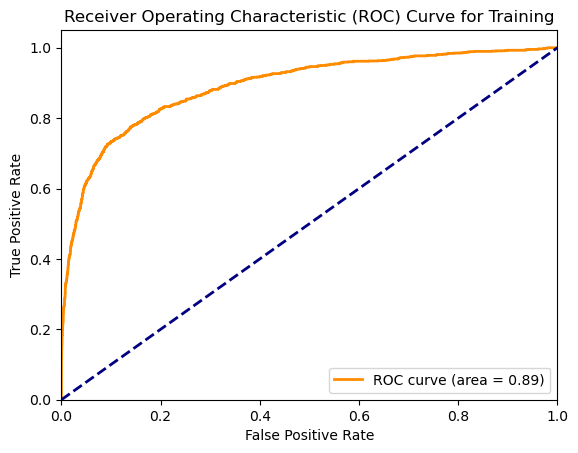

AUROC for Validation: 0.88


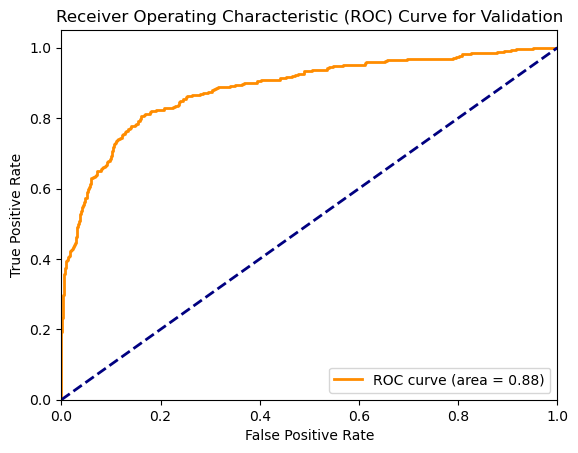

In [95]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

AUROC for Training: 0.89


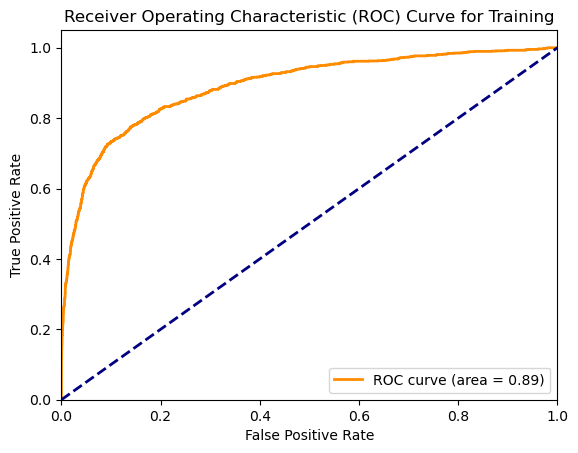

AUROC for Validation: 0.88


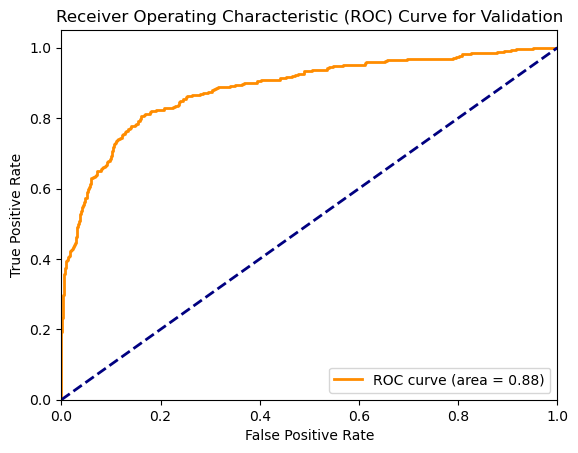

In [96]:
compute_auroc_and_build_roc(X_train_2, train_targets, 'Training')
compute_auroc_and_build_roc(X_val_2, val_targets, 'Validation')

## Обчислення F1 

In [97]:
train_f1 = f1_score(train_targets, train_preds, pos_label=1)
val_f1 = f1_score(val_targets, val_preds, pos_label=1)
print(f'Train F1 Score: {train_f1:.4f}')
print(f'Val   F1 Score: {val_f1:.4f}')

Train F1 Score: 0.6492
Val   F1 Score: 0.6381


### Висновок про якість моделі

- **Confusion Matrix**: модель добре розпізнає клас 0 (не відтік), але погано виявляє клас 1 (відтік).
- **AUROC**: значення 0.88 відповідає задовільній/хорошій моделі.
- **F1 Score**: низький F1 для класу 1 свідчить, що модель пропускає багато реальних відтоків.

**Загальний висновок:** модель є **задовільною** — вона непогано розпізнає більшість клієнтів, які залишаються, але погано ловить тих, хто відтікає.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [98]:
majority_class = train_targets['Exited'].mode()[0]

majority_train_preds = [majority_class] * len(train_targets)
majority_val_preds = [majority_class] * len(val_targets)

# Accuracy of baseline vs trained model
train_acc = accuracy_score(train_targets['Exited'], majority_train_preds)
val_acc = accuracy_score(val_targets['Exited'], majority_val_preds)

model_train_acc = accuracy_score(train_targets['Exited'], train_preds)
model_val_acc = accuracy_score(val_targets['Exited'], val_preds)

print(f'Majority class: {majority_class}')
print(f'Baseline train accuracy: {train_acc:.4f}')
print(f'Baseline val accuracy:   {val_acc:.4f}')
print(f'Model train accuracy:    {model_train_acc:.4f}')
print(f'Model val accuracy:      {model_val_acc:.4f}')

Majority class: 0.0
Baseline train accuracy: 0.7965
Baseline val accuracy:   0.7962
Model train accuracy:    0.8783
Model val accuracy:      0.8737


Модель помітно краща аніж та, яка передбачає за мажоритарним класом.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [99]:
model_artifacts = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [100]:
joblib.dump(model_artifacts, '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib')

['../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib']

In [101]:
model_2 = joblib.load('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [102]:
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, input_cols, numeric_cols, categorical_cols, encoded_cols, input_df: pd.DataFrame):
    input_df = input_df[input_cols].copy()
    input_df = add_engineered_features(input_df)
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    encoded_data = encoder.transform(input_df[categorical_cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=input_df.index)

    X_input = pd.concat([input_df[numeric_cols], encoded_df], axis=1)
    prob = model.predict_proba(X_input)[:, 1]
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [103]:
test_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/test.csv')
display(test_raw_df)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [104]:
test_raw_df["Exited"] = predict_raw_df(model, scaler, encoder, input_cols, numeric_cols, categorical_cols, encoded_cols, test_raw_df)

In [105]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.079720
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.031416
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.125032
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.141460
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.043587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.020291
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.019647
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.017815
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.147814


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [106]:
sample_submission_file = pd.read_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/sample_submission.csv'
)

sample_submission_df = sample_submission_file.drop(columns=['Exited']).merge(
    test_raw_df[['id', 'Exited']],
    on='id',
    how='left'
)

display(sample_submission_df.head())

,id,Exited
0,15000,0.079720
1,15001,0.031416
2,15002,0.125032
3,15003,0.141460
4,15004,0.043587


In [107]:
sample_submission_df.to_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/submission_log_reg.csv',
    index=False
)